Programming assignment 5: Dermatological image classification

G: 23, Omar alabdalla, Alamin Alreda and Anas Masri 

Loading and Normalizing Image Dataset in PyTorch

In [ ]:
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
from collections import Counter
torch.cuda.empty_cache()

train_path = './a5_data/a5_data/train'
val_path = './a5_data/a5_data/val'

#Load Dataset Without Augmentation (Baseline)

# No augmentation, just converting images to tensors
train_dataset = datasets.ImageFolder(train_path, transform=transforms.ToTensor())
val_dataset = datasets.ImageFolder(val_path, transform=transforms.ToTensor())

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Print dataset information
print("Classes:", train_dataset.classes)
print("Number of training images:", len(train_dataset))
print("Number of validation images:", len(val_dataset))
print("Training class distribution:", Counter(train_dataset.targets))
print("Validation class distribution:", Counter(val_dataset.targets))

def compute_mean_std(data_loader):
    mean = torch.zeros(3)
    std = torch.zeros(3)
    num_samples = 0

    for images, _ in data_loader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, 3, -1)
        mean += images.mean(dim=2).sum(dim=0)
        std += images.std(dim=2, unbiased=False).sum(dim=0) 
        num_samples += batch_samples

    mean /= num_samples
    std /= num_samples
    return mean, std

# Compute normalization values
mean, std = compute_mean_std(train_loader)
print("Trainset Mean:", mean.numpy())
print("Trainset Std:", std.numpy())

mean, std = compute_mean_std(val_loader)
print("valset Mean:", mean.numpy())
print("valset Std:", std.numpy())

Classes: ['MEL', 'NV']
Number of training images: 6426
Number of validation images: 1252
Training class distribution: Counter({0: 3213, 1: 3213})
Validation class distribution: Counter({0: 626, 1: 626})
Trainset Mean: [0.6836813  0.52313745 0.50991   ]
Trainset Std: [0.12973581 0.14989652 0.16331929]
valset Mean: [0.67682236 0.51938707 0.50563574]
valset Std: [0.1356678  0.15224802 0.1648821 ]


Visualize Images Before & After Augmentation

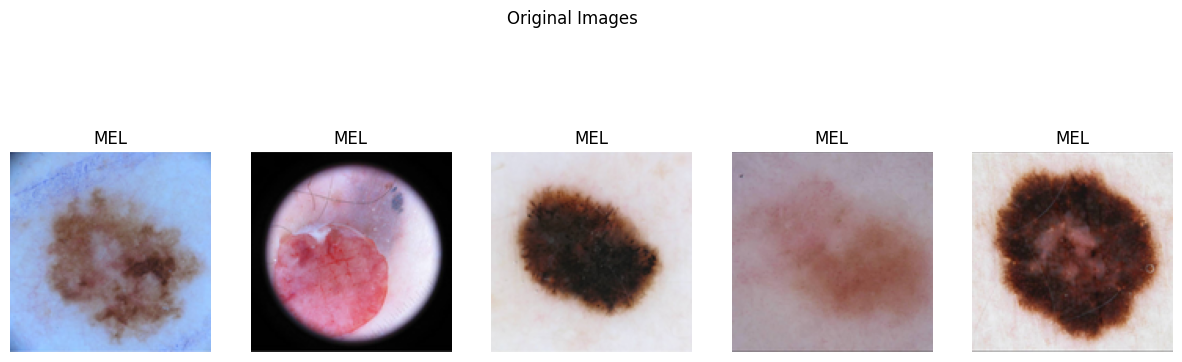

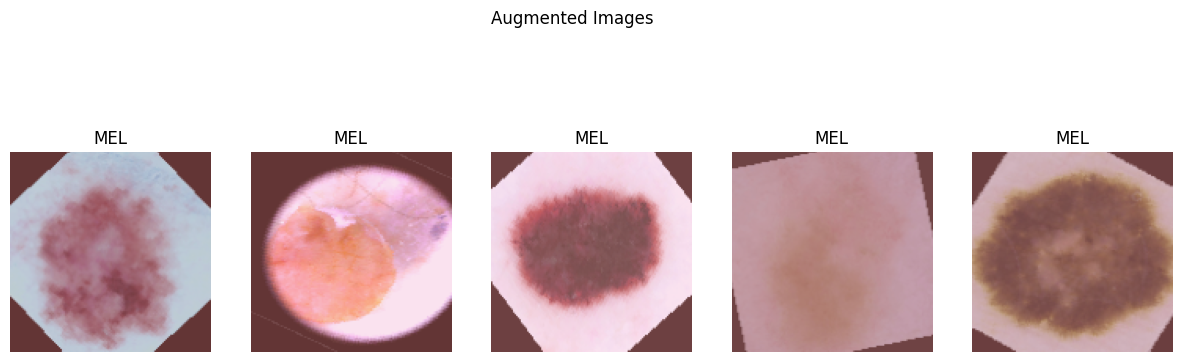

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(90),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dataset_augmen = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset_augmen = datasets.ImageFolder(val_path, transform=val_transform)

# DataLoaders
train_loader_augmen = DataLoader(train_dataset_augmen, batch_size=32, shuffle=True)
val_loader_augmen = DataLoader(val_dataset_augmen, batch_size=32, shuffle=False)

def denormalize(img, mean, std):
    """Undo normalization to convert back to [0,1] range for visualization"""
    mean = mean.view(1, 1, 3)  # Ensure mean is in the correct shape
    std = std.view(1, 1, 3)    # Ensure std is in the correct shape
    img = img * std + mean  # Reverse normalization
    return torch.clamp(img, 0, 1)  # Ensure values are in [0,1]


def show_images_original(dataset, title):
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    for i in range(5):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)
        axes[i].imshow(img)
        axes[i].set_title(train_dataset.classes[label])
        axes[i].axis("off")
    plt.suptitle(title)
    plt.show()

def show_images_aug(dataset, title, mean, std):
    fig, axes = plt.subplots(1, 5, figsize=(15, 5))
    for i in range(5):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)  # Convert from (C, H, W) to (H, W, C)
        img = denormalize(img, mean, std)  # Fix image range
        axes[i].imshow(img)
        axes[i].set_title(dataset.classes[label])
        axes[i].axis("off")
    plt.suptitle(title)
    plt.show()

# Show original images
show_images_original(train_dataset, "Original Images")

# Show augmented images
show_images_aug(train_dataset_augmen, "Augmented Images", mean, std)




Training and Evaluating a Binary Classifier in PyTorch

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import accuracy_score ,precision_score, recall_score, f1_score, roc_auc_score
import torch.optim as optim


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_classifier(model, train_data, val_data, hyperparams):
    model.to(device) 

    optimizer = torch.optim.Adam(model.parameters(), lr=hyperparams['lr']) 
    loss_func = torch.nn.BCEWithLogitsLoss() 
   

    acc_history = []
    best_accuracy = 0.0  
    best_model_path = "best_model.pth" 

    for epoch in range(hyperparams['n_epochs']):
        model.train()
        loss_sum = 0
        for Xbatch, Ybatch in tqdm(train_data):

            Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device) 
            optimizer.zero_grad()
            outputs = model(Xbatch)
            loss = loss_func(outputs, Ybatch.unsqueeze(1).float())
        
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        # Evaluate on validation set
        model.eval()
        with torch.no_grad():
            val_acc = predict_and_evaluate(model, val_data)

        mean_loss = loss_sum / len(train_data)
        acc_history.append(val_acc)
        
        print(f'Epoch {epoch+1}: loss = {mean_loss:.4f}, val acc = {val_acc:.4f}')

        # Save the model if validation accuracy improves
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            torch.save(model.state_dict(), best_model_path)
    return acc_history

def predict_and_evaluate(model, data):
    model.to(device)

    all_gold = []
    all_pred = []
    
    for Xbatch, Ybatch in data:
        Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
        outputs = model(Xbatch)

        predictions = (torch.sigmoid(outputs).squeeze() > 0.5).float() # using sigmoid 
        all_gold.extend(Ybatch.cpu().numpy()) 
        all_pred.extend(predictions.cpu().numpy())

    return accuracy_score(all_gold, all_pred)


Baseline Module

In [ ]:
import torch.nn.functional as F 
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1= nn.Conv2d(3, 16, kernel_size=3, padding=1) 
        self.conv2=nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc= nn.Linear(32 * 32 * 32, 50)
        self.output=nn.Linear(50, 1)
    def forward(self, X):
        c1=self.conv1(X)
        fm1=F.max_pool2d(F.relu(c1), 2)
        c2=self.conv2(fm1)
        fm2=F.max_pool2d(F.relu(c2),2)
        f1=torch.flatten(fm2, start_dim=1)
        h1=F.relu(self.fc(f1))
        out=self.output(h1)
        return out
    
torch.random.manual_seed(2)
cnn1 = SimpleCNN()

#run datasets before augmentation
history = train_classifier(cnn1, train_loader, val_loader, {'lr': 1e-3, 'n_epochs': 10})



100%|██████████| 201/201 [00:08<00:00, 23.32it/s]


Epoch 1: loss = 0.4654, val acc = 0.7732


100%|██████████| 201/201 [00:10<00:00, 18.68it/s]


Epoch 2: loss = 0.4125, val acc = 0.7700


100%|██████████| 201/201 [00:10<00:00, 18.72it/s]


...

Epoch 8: loss = 0.3035, val acc = 0.8179


100%|██████████| 201/201 [00:10<00:00, 18.81it/s]


Epoch 9: loss = 0.2840, val acc = 0.8107


100%|██████████| 201/201 [00:10<00:00, 18.66it/s]


Epoch 10: loss = 0.2785, val acc = 0.8339


In [11]:
#using augmentation data sets 
history = train_classifier(cnn1, train_loader_augmen, val_loader_augmen, {'lr': 1e-3, 'n_epochs': 10})

100%|██████████| 201/201 [00:24<00:00,  8.05it/s]


Epoch 1: loss = 0.3964, val acc = 0.8379


100%|██████████| 201/201 [00:24<00:00,  8.33it/s]


Epoch 2: loss = 0.3849, val acc = 0.8163


100%|██████████| 201/201 [00:24<00:00,  8.36it/s]


...

Epoch 8: loss = 0.3702, val acc = 0.8490


100%|██████████| 201/201 [00:27<00:00,  7.26it/s]


Epoch 9: loss = 0.3722, val acc = 0.8139


100%|██████████| 201/201 [00:26<00:00,  7.65it/s]


Epoch 10: loss = 0.3689, val acc = 0.8171


Tuning parameters:

In [ ]:
# 1: lr
print('Tuning lr:')
# Experiment with different learning rates
lr_values = [1e-5, 1e-4, 1e-3,5e-4, 1e-2, 0.005 ]


# Define a dictionary to store the results of each lr
results = {}

for lr in lr_values:
    print(f'Training with learning rate: {lr}')
    # Use the specified learning rate in the training process
    history = train_classifier(cnn1, train_loader_augmen, val_loader_augmen, {'lr': lr, 'n_epochs': 10})
    results[lr] = history  # Store the results

# Evaluate the best learning rate based on validation accuracy
best_lr = max(results, key=lambda lr: max(results[lr]))
print(f"Best learning rate: {best_lr}")

Tuning lr:
Training with learning rate: 1e-05


100%|██████████| 201/201 [00:23<00:00,  8.40it/s]


Epoch 1: loss = 0.3670, val acc = 0.8323


100%|██████████| 201/201 [00:37<00:00,  5.41it/s]


Epoch 2: loss = 0.3576, val acc = 0.8339


...

Epoch 8: loss = 0.4038, val acc = 0.8147


100%|██████████| 201/201 [00:25<00:00,  7.98it/s]


Epoch 9: loss = 0.4032, val acc = 0.8147


100%|██████████| 201/201 [00:25<00:00,  7.98it/s]


Epoch 10: loss = 0.3960, val acc = 0.8195
Best learning rate: 0.0001


The best lr values = 5e-4 and 1e-3

BatchNormalization

In [16]:
import torch.nn.functional as F 
import torch.nn as nn



class BatchNormalization_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1= nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1=nn.BatchNorm2d(16) 
        self.conv2=nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2=nn.BatchNorm2d(32) 
        self.fc= nn.Linear(32 * 32 * 32, 50)
        self.bn3 = nn.BatchNorm1d(50) 
        self.output=nn.Linear(50, 1)
    def forward(self, X):
        c1=self.conv1(X)
        c1 = self.bn1(c1)
        fm1=F.max_pool2d(F.relu(c1), 2)
        c2=self.conv2(fm1)
        c2 = self.bn2(c2)
        fm2=F.max_pool2d(F.relu(c2),2)
        f1=torch.flatten(fm2, start_dim=1)
        h1 = self.bn3(self.fc(f1)) 
        h1 = F.relu(h1)
        out=self.output(h1)
        return out
    

torch.random.manual_seed(2)
cnn2 = BatchNormalization_CNN()
print('Lr=1e-3')
history = train_classifier(cnn2, train_loader_augmen, val_loader_augmen, {'lr': 1e-3, 'n_epochs': 10})
print('Lr=5e-4')
history = train_classifier(cnn2, train_loader_augmen, val_loader_augmen, {'lr': 5e-4, 'n_epochs': 10})


Lr=1e-3


100%|██████████| 201/201 [00:21<00:00,  9.43it/s]


Epoch 1: loss = 0.5178, val acc = 0.7883


100%|██████████| 201/201 [00:21<00:00,  9.34it/s]


Epoch 2: loss = 0.4756, val acc = 0.8011


...

Epoch 8: loss = 0.3786, val acc = 0.8395


100%|██████████| 201/201 [00:26<00:00,  7.65it/s]


Epoch 9: loss = 0.3826, val acc = 0.8395


100%|██████████| 201/201 [00:27<00:00,  7.21it/s]


Epoch 10: loss = 0.3745, val acc = 0.8347


ResidualConnections

In [ ]:
import torch.nn.functional as F
import torch.nn as nn

class BatchNorm_Residual_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.fc = nn.Linear(32 * 16 * 16, 50) 
        self.bn3 = nn.BatchNorm1d(50)
        self.output = nn.Linear(50, 1)
        self.conv_res = nn.Conv2d(16, 32, kernel_size=1)

    def forward(self, X):
        c1 = self.conv1(X)
        c1 = self.bn1(c1)
        fm1 = F.max_pool2d(F.relu(c1), 2)
        c2 = self.conv2(fm1)
        c2 = self.bn2(c2)
        fm2 = F.max_pool2d(F.relu(c2), 2)
        fm1_res = F.interpolate(fm1, size=fm2.shape[2:], mode='bilinear', align_corners=False)
        fm1_res = self.conv_res(fm1_res)
        res = fm1_res + fm2
        res = F.max_pool2d(res, 2)
        f1 = torch.flatten(res, start_dim=1)  # Flatten except batch dimension
        h1 = self.fc(f1)  # Apply fully connected layer first
        h1 = self.bn3(h1)  # Then apply batch normalization
        h1 = F.relu(h1)   # Finally apply ReLU activation
        out = self.output(h1)
        return out

torch.random.manual_seed(2)
cnn1 = BatchNorm_Residual_CNN()
history = train_classifier(cnn1, train_loader_augmen, val_loader_augmen, {'lr': 5e-4, 'n_epochs': 10})


100%|██████████| 201/201 [00:21<00:00,  9.27it/s]


Epoch 1: loss = 0.4862, val acc = 0.7979


100%|██████████| 201/201 [00:22<00:00,  9.06it/s]


Epoch 2: loss = 0.4488, val acc = 0.8043


100%|██████████| 201/201 [00:22<00:00,  8.76it/s]


...

Epoch 8: loss = 0.3950, val acc = 0.8323


100%|██████████| 201/201 [00:26<00:00,  7.47it/s]


Epoch 9: loss = 0.3987, val acc = 0.8227


100%|██████████| 201/201 [00:24<00:00,  8.34it/s]


Epoch 10: loss = 0.3901, val acc = 0.8107


Pre-trained:
1-VGG16

In [ ]:
#this
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch import nn
from torch.utils.data import DataLoader

# Load VGG-16 pre-trained model
weights_id = torchvision.models.VGG16_Weights.IMAGENET1K_V1
vgg_model = torchvision.models.vgg16(weights=weights_id)

# Freeze feature extractor (Convolutional layers)
for param in vgg_model.features.parameters():
    param.requires_grad = False

# Extract feature extractor
feature_extractor = vgg_model.features  # CNN layers

# Create new classifier using nn.Sequential
new_classifier = nn.Sequential(
    nn.Linear(vgg_model.classifier[0].in_features, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1),  # Binary classification (1 output)
)

# Build new model
model = nn.Sequential(
    feature_extractor,  # CNN feature extractor
    nn.Flatten(),  # Flatten before passing to classifier
    new_classifier  # New classifier
)

# Set model to evaluation mode
model.eval()

# Apply ImageNet transformations
vgg_transforms = weights_id.transforms()

# Train Transform (Augmentations + VGG Transforms)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Ensure correct input size
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Match VGG-16 input size
    vgg_transforms  # Apply pre-trained model's transforms (already includes normalization)
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    vgg_transforms  # Apply pre-trained model's transforms
])

# Create Datasets & Dataloaders
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset = datasets.ImageFolder(val_path, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
# Train model
history = train_classifier(model, train_loader, val_loader, {'lr': 5e-4, 'n_epochs': 10})


100%|██████████| 201/201 [00:57<00:00,  3.51it/s]


Epoch 1: loss = 0.4653, val acc = 0.8355


100%|██████████| 201/201 [00:59<00:00,  3.36it/s]


Epoch 2: loss = 0.3573, val acc = 0.8419


100%|██████████| 201/201 [00:59<00:00,  3.37it/s]


...

Epoch 8: loss = 0.2803, val acc = 0.8626


100%|██████████| 201/201 [01:01<00:00,  3.25it/s]


Epoch 9: loss = 0.2832, val acc = 0.8642


100%|██████████| 201/201 [01:03<00:00,  3.16it/s]


Epoch 10: loss = 0.2654, val acc = 0.8690


In [ ]:
# testing 90 degrees rotation instead of 30
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch import nn
from torch.utils.data import DataLoader

# Load VGG-16 pre-trained model
weights_id = torchvision.models.VGG16_Weights.IMAGENET1K_V1
vgg_model = torchvision.models.vgg16(weights=weights_id)

# Freeze feature extractor (Convolutional layers)
for param in vgg_model.features.parameters():
    param.requires_grad = False

# Extract feature extractor
feature_extractor = vgg_model.features  # CNN layers (unchanged)

# Create new classifier using nn.Sequential
new_classifier = nn.Sequential(
    nn.Linear(vgg_model.classifier[0].in_features, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1), 
)

# Build new model
model = nn.Sequential(
    feature_extractor, 
    nn.Flatten(),  
    new_classifier 
)


model.eval()


vgg_transforms = weights_id.transforms()


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Ensure correct input size
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(90),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Match VGG-16 input size
    vgg_transforms 
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    vgg_transforms  # Apply pre-trained model's transforms
])

# Create Datasets & Dataloaders
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset = datasets.ImageFolder(val_path, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Train model
history = train_classifier(model, train_loader, val_loader, {'lr': 5e-4, 'n_epochs': 10})


100%|██████████| 201/201 [00:53<00:00,  3.78it/s]


Epoch 1: loss = 0.4785, val acc = 0.8315


100%|██████████| 201/201 [01:02<00:00,  3.23it/s]


Epoch 2: loss = 0.3787, val acc = 0.8419


100%|██████████| 201/201 [01:04<00:00,  3.13it/s]


...

Epoch 8: loss = 0.3144, val acc = 0.8578


100%|██████████| 201/201 [00:58<00:00,  3.46it/s]


Epoch 9: loss = 0.3142, val acc = 0.8634


100%|██████████| 201/201 [00:58<00:00,  3.45it/s]


Epoch 10: loss = 0.3111, val acc = 0.8546


pre-trained , 
2-Vgg19

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch import nn
from torch.utils.data import DataLoader

# Load VGG-19 pre-trained model
weights_id = torchvision.models.VGG19_Weights.IMAGENET1K_V1
vgg_model = torchvision.models.vgg19(weights=weights_id)

# Freeze feature extractor (Convolutional layers)
for param in vgg_model.features.parameters():
    param.requires_grad = False

# Extract feature extractor
feature_extractor = vgg_model.features 

# Create new classifier using nn.Sequential
new_classifier = nn.Sequential(
    nn.Linear(vgg_model.classifier[0].in_features, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1)  # Binary classification (1 output)
)

# Build new model
model = nn.Sequential(
    feature_extractor,  # CNN feature extractor
    nn.Flatten(),  # Flatten before passing to classifier
    new_classifier  # New classifier
)

# Set model to evaluation mode
model.eval()

# Apply ImageNet transformations
vgg_transforms = weights_id.transforms()

# Train Transform (Augmentations + VGG Transforms)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Ensure correct input size
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Match VGG-19 input size
    vgg_transforms 
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    vgg_transforms  # Apply pre-trained model's transforms
])

# Create Datasets & Dataloaders
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset = datasets.ImageFolder(val_path, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Train model
history = train_classifier(model, train_loader, val_loader, {'lr': 5e-4, 'n_epochs': 10})


100%|██████████| 201/201 [01:09<00:00,  2.88it/s]


Epoch 1: loss = 0.4617, val acc = 0.8315


100%|██████████| 201/201 [01:08<00:00,  2.93it/s]


Epoch 2: loss = 0.3750, val acc = 0.8379


100%|██████████| 201/201 [01:09<00:00,  2.89it/s]


...

Epoch 8: loss = 0.3051, val acc = 0.8530


100%|██████████| 201/201 [01:07<00:00,  2.96it/s]


Epoch 9: loss = 0.3022, val acc = 0.8546


100%|██████████| 201/201 [01:03<00:00,  3.16it/s]


Epoch 10: loss = 0.2976, val acc = 0.8538


In [ ]:
# testing 90 degrees rotation
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch import nn
from torch.utils.data import DataLoader


weights_id = torchvision.models.VGG19_Weights.IMAGENET1K_V1
vgg_model = torchvision.models.vgg19(weights=weights_id)


for param in vgg_model.features.parameters():
    param.requires_grad = False

# Extract feature extractor
feature_extractor = vgg_model.features 

# Create new classifier using nn.Sequential
new_classifier = nn.Sequential(
    nn.Linear(vgg_model.classifier[0].in_features, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1)
)


model = nn.Sequential(
    feature_extractor,
    nn.Flatten(), 
    new_classifier 
)


model.eval()


vgg_transforms = weights_id.transforms()


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Ensure correct input size
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(90),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Match VGG-19 input size
    vgg_transforms 
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    vgg_transforms  
])

# Create Datasets & Dataloaders
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset = datasets.ImageFolder(val_path, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Train model
history = train_classifier(model, train_loader, val_loader, {'lr': 5e-4, 'n_epochs': 10})


100%|██████████| 201/201 [01:00<00:00,  3.32it/s]


Epoch 1: loss = 0.4758, val acc = 0.8251


100%|██████████| 201/201 [01:01<00:00,  3.25it/s]


Epoch 2: loss = 0.3883, val acc = 0.8442


100%|██████████| 201/201 [01:03<00:00,  3.16it/s]


...

Epoch 8: loss = 0.3331, val acc = 0.8530


100%|██████████| 201/201 [01:07<00:00,  2.99it/s]


Epoch 9: loss = 0.3265, val acc = 0.8530


100%|██████████| 201/201 [01:08<00:00,  2.94it/s]


Epoch 10: loss = 0.3269, val acc = 0.8411


Pre-trained, 3-ResNet-18

In [ ]:
#run this
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch import nn
from torch.utils.data import DataLoader

# Load ResNet-18 pre-trained model
weights_id = torchvision.models.ResNet18_Weights.IMAGENET1K_V1
resnet_model = torchvision.models.resnet18(weights=weights_id)

# Freeze feature extractor (Convolutional layers)
for param in resnet_model.parameters():
    param.requires_grad = False

# Modify the classifier for binary classification
num_features = resnet_model.fc.in_features  # Get input features of the last FC layer

resnet_model.fc = nn.Sequential(
    nn.Linear(num_features, 4096), 
    nn.ReLU(),
     nn.Dropout(0.5),
    nn.Linear(4096, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1)  # Final output layer (1 neuron for binary classification)
)
# Set model to evaluation mode
resnet_model.eval()

# Apply ImageNet transformations
resnet_transforms = weights_id.transforms()

# Train Transform (Augmentations + ResNet Transforms)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Ensure correct input size
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Match ResNet input size
    resnet_transforms  
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    resnet_transforms 
])

# Create Datasets & Dataloaders
train_dataset = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset = datasets.ImageFolder(val_path, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Train model
history = train_classifier(resnet_model, train_loader, val_loader, {'lr': 5e-4, 'n_epochs': 10})


100%|██████████| 201/201 [00:27<00:00,  7.24it/s]


Epoch 1: loss = 0.4840, val acc = 0.8259


100%|██████████| 201/201 [00:30<00:00,  6.51it/s]


Epoch 2: loss = 0.4009, val acc = 0.8403


100%|██████████| 201/201 [00:39<00:00,  5.14it/s]


...

Epoch 8: loss = 0.3689, val acc = 0.8482


100%|██████████| 201/201 [00:36<00:00,  5.55it/s]


Epoch 9: loss = 0.3620, val acc = 0.8618


100%|██████████| 201/201 [00:34<00:00,  5.79it/s]


Epoch 10: loss = 0.3729, val acc = 0.8514


Pre-trained 4-dinov2

In [ ]:
#basic
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_path = './a5_data/a5_data/train'
val_path = './a5_data/a5_data/val'
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').cuda()
for param in dinov2.parameters():
    param.requires_grad_(False)
dinov2.eval()
model_dinov_2 = nn.Sequential(
    dinov2,
    nn.Linear(384, 512), 
    nn.ReLU(),                
    nn.Linear(512, 256),       
    nn.ReLU(),                 
    nn.Linear(256, 1)          
)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_dataset_augmen = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset_augmen = datasets.ImageFolder(val_path, transform=val_transform)

train_loader_augmen_2 = DataLoader(train_dataset_augmen, batch_size=32, shuffle=True)
val_loader_augmen_2 = DataLoader(val_dataset_augmen, batch_size=32, shuffle=False)
Classifier_final = train_classifier(model_dinov_2, train_loader_augmen_2, val_loader_augmen_2, {'lr': 5e-4, 'n_epochs': 10})


Using cache found in C:\Users\omara/.cache\torch\hub\facebookresearch_dinov2_main
100%|██████████| 201/201 [00:39<00:00,  5.09it/s]


Epoch 1: loss = 0.3508, val acc = 0.8618


100%|██████████| 201/201 [00:48<00:00,  4.18it/s]


Epoch 2: loss = 0.2956, val acc = 0.8331


100%|██████████| 201/201 [00:44<00:00,  4.54it/s]


...

Epoch 8: loss = 0.2240, val acc = 0.8754


100%|██████████| 201/201 [00:44<00:00,  4.51it/s]


Epoch 9: loss = 0.2118, val acc = 0.8722


100%|██████████| 201/201 [00:44<00:00,  4.49it/s]


Epoch 10: loss = 0.2045, val acc = 0.8834


Fine-Tuning DINOv2 (best module)for Image Classification with Data Augmentation

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

train_path = './a5_data/a5_data/train'
val_path = './a5_data/a5_data/val'

# Load DINOv2 pre-trained model
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').cuda()

# Freeze all parameters in the DINOv2 model
for param in dinov2.parameters():
    param.requires_grad_(False)



N = 2
for param in list(dinov2.blocks[-N:].parameters()):  # Unfreeze last 2 transformer blocks
    param.requires_grad_(True)
    
dinov2.eval()

model_dinov_2 = nn.Sequential(
    dinov2,
    nn.Linear(384, 512),  
    nn.ReLU(),                
    nn.Linear(512, 256),       
    nn.ReLU(),                 
    nn.Linear(256, 1)          
)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dataset_augmen = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset_augmen = datasets.ImageFolder(val_path, transform=val_transform)

train_loader_augmen_2 = DataLoader(train_dataset_augmen, batch_size=32, shuffle=True)
val_loader_augmen_2 = DataLoader(val_dataset_augmen, batch_size=32, shuffle=False)


Classifier_final = train_classifier(model_dinov_2, train_loader_augmen_2, val_loader_augmen_2, {'lr': 5e-4, 'n_epochs': 10})


Using cache found in C:\Users\omara/.cache\torch\hub\facebookresearch_dinov2_main
100%|██████████| 201/201 [03:07<00:00,  1.07it/s]


Epoch 1: loss = 0.3988, val acc = 0.8538


100%|██████████| 201/201 [02:41<00:00,  1.24it/s]


Epoch 2: loss = 0.2949, val acc = 0.8450


100%|██████████| 201/201 [04:31<00:00,  1.35s/it]


...

Epoch 8: loss = 0.2620, val acc = 0.8794


100%|██████████| 201/201 [00:48<00:00,  4.12it/s]


Epoch 9: loss = 0.2453, val acc = 0.8818


100%|██████████| 201/201 [00:49<00:00,  4.08it/s]


Epoch 10: loss = 0.2678, val acc = 0.8818


In [ ]:
#with dropout to avoid overfitting
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Load DINOv2 pre-trained model
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').cuda()

# Freeze all parameters in the DINOv2 model
for param in dinov2.parameters():
    param.requires_grad_(False)

dinov2.eval()

# Define the sequential model with DINOv2 and additional linear layers
model = nn.Sequential(
    dinov2,
    nn.Flatten(),
    nn.Linear(384, 4096),   # First linear layer
    nn.ReLU(),# ReLU activation
    nn.Dropout(0.5),
    nn.Linear(4096, 4096),        # Second linear layer
    nn.ReLU(),                  # ReLU activation
    nn.Dropout(0.5),
    nn.Linear(4096, 1)           # Output layer (binary classification)
)

# Data augmentation for training set
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224 to match DINOv2 input size
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Random resize crop
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Validation transform (no augmentation, just normalization)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Load datasets with the new transformations
train_dataset_augmen = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset_augmen = datasets.ImageFolder(val_path, transform=val_transform)

# Create DataLoader for batches
train_loader_augmen_2 = DataLoader(train_dataset_augmen, batch_size=32, shuffle=True)
val_loader_augmen_2 = DataLoader(val_dataset_augmen, batch_size=32, shuffle=False)

# Train model
Classifier = train_classifier(model, train_loader_augmen_2, val_loader_augmen_2, {'lr': 5e-4, 'n_epochs': 10})


Using cache found in C:\Users\omara/.cache\torch\hub\facebookresearch_dinov2_main
100%|██████████| 201/201 [01:18<00:00,  2.57it/s]


Epoch 1: loss = 0.4169, val acc = 0.7851


100%|██████████| 201/201 [00:44<00:00,  4.53it/s]


Epoch 2: loss = 0.3240, val acc = 0.8562


100%|██████████| 201/201 [00:44<00:00,  4.57it/s]


...

Epoch 8: loss = 0.2579, val acc = 0.8826


100%|██████████| 201/201 [00:44<00:00,  4.56it/s]


Epoch 9: loss = 0.2553, val acc = 0.8810


100%|██████████| 201/201 [00:43<00:00,  4.57it/s]


Epoch 10: loss = 0.2552, val acc = 0.8674


Tuning the optimizer and loss fuction for the best socre model

In [ ]:
# modify the train function
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import accuracy_score ,precision_score, recall_score, f1_score, roc_auc_score
import torch.optim as optim


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_classifier_update(model, train_data, val_data,optimizer, loss_func, hyperparams):
    model.to(device) 

    
   

    acc_history = []
    best_accuracy = 0.0  
    best_model_path = "best_model.pth" 

    for epoch in range(hyperparams['n_epochs']):
        model.train()
        loss_sum = 0
        for Xbatch, Ybatch in tqdm(train_data):
        #for Xbatch, Ybatch in train_data:

            Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device) 
            optimizer.zero_grad()
            outputs = model(Xbatch)
            loss = loss_func(outputs, Ybatch.unsqueeze(1).float())
        
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        # Evaluate on validation set
        model.eval()
        with torch.no_grad():
            val_acc = predict_and_evaluate(model, val_data)

        mean_loss = loss_sum / len(train_data)
        acc_history.append(val_acc)
        
        print(f'Epoch {epoch+1}: loss = {mean_loss:.4f}, val acc = {val_acc:.4f}')

        # Save the model if validation accuracy improves
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            torch.save(model.state_dict(), best_model_path)
    return acc_history

def predict_and_evaluate(model, data):
    model.to(device)

    all_gold = []
    all_pred = []
    
    for Xbatch, Ybatch in data:
        Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
        outputs = model(Xbatch)

        predictions = (torch.sigmoid(outputs).squeeze() > 0.5).float()
        all_gold.extend(Ybatch.cpu().numpy()) 
        all_pred.extend(predictions.cpu().numpy())

    return accuracy_score(all_gold, all_pred)


Testing SGD

In [ ]:

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').cuda()
for param in dinov2.parameters():
    param.requires_grad_(False)

dinov2.eval()
model = nn.Sequential(
    dinov2,
    nn.Linear(384, 512), 
    nn.ReLU(),               
    nn.Linear(512, 256),      
    nn.ReLU(),              
    nn.Linear(256, 1)          
)


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

train_dataset_augmen = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset_augmen = datasets.ImageFolder(val_path, transform=val_transform)


train_loader_augmen_2 = DataLoader(train_dataset_augmen, batch_size=32, shuffle=True)
val_loader_augmen_2 = DataLoader(val_dataset_augmen, batch_size=32, shuffle=False)

hyperparameters = {'lr': 5e-4, 'n_epochs': 10}
# SGD Optimizer with momentum and weight decay (for regularization)
optimizer = torch.optim.SGD(model.parameters(), lr=hyperparameters['lr'])
loss_func = torch.nn.BCEWithLogitsLoss() 
# Train model
Classifier = train_classifier_update(model, train_loader_augmen_2, val_loader_augmen_2, optimizer, loss_func,hyperparameters)


Using cache found in C:\Users\omara/.cache\torch\hub\facebookresearch_dinov2_main
100%|██████████| 201/201 [00:36<00:00,  5.44it/s]


Epoch 1: loss = 0.6726, val acc = 0.7636


100%|██████████| 201/201 [00:38<00:00,  5.22it/s]


Epoch 2: loss = 0.6289, val acc = 0.8051


100%|██████████| 201/201 [00:43<00:00,  4.60it/s]


...

Epoch 8: loss = 0.4488, val acc = 0.8299


100%|██████████| 201/201 [00:43<00:00,  4.64it/s]


Epoch 9: loss = 0.4298, val acc = 0.8323


100%|██████████| 201/201 [00:44<00:00,  4.47it/s]


Epoch 10: loss = 0.4187, val acc = 0.8307


Tuning the hyper parameters for the sgd

In [ ]:

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').cuda()

for param in dinov2.parameters():
    param.requires_grad_(False)

dinov2.eval()


model = nn.Sequential(
    dinov2,
    nn.Linear(384, 512),  
    nn.ReLU(),                 
    nn.Linear(512, 256),      
    nn.ReLU(),               
    nn.Linear(256, 1)          
)


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])


train_dataset_augmen = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset_augmen = datasets.ImageFolder(val_path, transform=val_transform)


train_loader_augmen_2 = DataLoader(train_dataset_augmen, batch_size=32, shuffle=True)
val_loader_augmen_2 = DataLoader(val_dataset_augmen, batch_size=32, shuffle=False)

hyperparameters = {'lr': 5e-4, 'n_epochs': 10}
# SGD Optimizer with momentum and weight decay (for regularization)
optimizer = torch.optim.SGD(model.parameters(), lr=hyperparameters['lr'], momentum=0.9, weight_decay=1e-4)
loss_func = torch.nn.BCEWithLogitsLoss() 


# Train model
Classifier = train_classifier_update(model, train_loader_augmen_2, val_loader_augmen_2, optimizer, loss_func,hyperparameters)


Using cache found in C:\Users\omara/.cache\torch\hub\facebookresearch_dinov2_main
100%|██████████| 201/201 [01:13<00:00,  2.74it/s]


Epoch 1: loss = 0.5507, val acc = 0.7883


100%|██████████| 201/201 [01:07<00:00,  2.99it/s]


Epoch 2: loss = 0.3888, val acc = 0.8339


100%|██████████| 201/201 [00:45<00:00,  4.42it/s]


...

Epoch 8: loss = 0.2917, val acc = 0.8586


100%|██████████| 201/201 [00:43<00:00,  4.61it/s]


Epoch 9: loss = 0.2903, val acc = 0.8586


100%|██████████| 201/201 [00:43<00:00,  4.58it/s]


Epoch 10: loss = 0.2812, val acc = 0.8586


Tuning Hyper paramerters for Adam

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').cuda()
for param in dinov2.parameters():
    param.requires_grad_(False)

dinov2.eval()


model = nn.Sequential(
    dinov2,
    nn.Linear(384, 512),  
    nn.ReLU(),                 
    nn.Linear(512, 256),      
    nn.ReLU(),                
    nn.Linear(256, 1)        
)


train_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  
])


train_dataset_augmen = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset_augmen = datasets.ImageFolder(val_path, transform=val_transform)

# Create DataLoader for batches
train_loader_augmen_2 = DataLoader(train_dataset_augmen, batch_size=32, shuffle=True)
val_loader_augmen_2 = DataLoader(val_dataset_augmen, batch_size=32, shuffle=False)

hyperparameters = {'lr': 5e-4, 'n_epochs': 10}
# SGD Optimizer with momentum and weight decay (for regularization)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,  
    betas=(0.9, 0.999),  
    eps=1e-8,  
    weight_decay=1e-5,  # Adding a small amount of L2 regularization
    amsgrad=False  
)

loss_func = torch.nn.BCEWithLogitsLoss() 


# Train model
Classifier = train_classifier_update(model, train_loader_augmen_2, val_loader_augmen_2, optimizer, loss_func,hyperparameters)


Using cache found in C:\Users\omara/.cache\torch\hub\facebookresearch_dinov2_main
100%|██████████| 201/201 [00:44<00:00,  4.49it/s]


Epoch 1: loss = 0.3661, val acc = 0.8395


100%|██████████| 201/201 [00:42<00:00,  4.77it/s]


Epoch 2: loss = 0.2949, val acc = 0.8610


100%|██████████| 201/201 [00:42<00:00,  4.71it/s]


...

Epoch 8: loss = 0.2290, val acc = 0.8834


100%|██████████| 201/201 [00:58<00:00,  3.46it/s]


Epoch 9: loss = 0.2206, val acc = 0.8690


100%|██████████| 201/201 [01:18<00:00,  2.55it/s]


Epoch 10: loss = 0.2138, val acc = 0.8650


1. Learning Rate Scheduling (ReduceLRonPlateau)
2. Enhanced Data Augmentation (Color Jitter)
3. Increased Training Epochs
4. Batch Normalization after Linear Layers
5. Fine-Tuning Some Layers of DINOv2
6. Slight Increase in Weight Decay

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_classifier_3(model, optimizer, loss_func, scheduler, train_loader, val_loader, hyperparams):
    model.to(device) 

    acc_history = []
    best_accuracy = 0.0  
    best_model_path = "best_model.pth" 

    for epoch in range(hyperparams['n_epochs']):
        model.train()
        loss_sum = 0

        for Xbatch, Ybatch in tqdm(train_loader):
            Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device) 

            optimizer.zero_grad()
            outputs = model(Xbatch)
            loss = loss_func(outputs, Ybatch.unsqueeze(1).float())
        
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        # Step the learning rate scheduler
        scheduler.step(loss_sum)  

        # Evaluate on validation set
        model.eval()
        with torch.no_grad():
            val_acc = predict_and_evaluate(model, val_loader)

        mean_loss = loss_sum / len(train_loader)
        acc_history.append(val_acc)
        
        print(f'Epoch {epoch+1}: loss = {mean_loss:.4f}, val acc = {val_acc:.4f}, lr = {scheduler.get_last_lr()[0]:.6f}')

        # Save the model if validation accuracy improves
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            torch.save(model.state_dict(), best_model_path)

    return acc_history

def predict_and_evaluate(model, data):
    model.to(device)

    all_gold = []
    all_pred = []
    
    for Xbatch, Ybatch in data:
        Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
        outputs = model(Xbatch)

        predictions = (torch.sigmoid(outputs).squeeze() > 0.5).float()
        
        all_gold.extend(Ybatch.cpu().numpy()) 
        all_pred.extend(predictions.cpu().numpy())

    return accuracy_score(all_gold, all_pred)

# Load DINOv2 pre-trained model
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').cuda()

# Freeze all parameters in the DINOv2 model (except the final layers for fine-tuning)
for param in dinov2.parameters():
    param.requires_grad = False

# Unfreeze the last few layers for fine-tuning
for param in dinov2.head.parameters():
    param.requires_grad = True

dinov2.eval()

# Define the sequential model with DINOv2 and additional linear layers
model = nn.Sequential(
    dinov2,
    nn.Linear(384, 512),   # First linear layer
    nn.ReLU(),             # ReLU activation
    nn.BatchNorm1d(512),   # Batch Normalization
    nn.Linear(512, 256),   # Second linear layer
    nn.ReLU(),             # ReLU activation
    nn.BatchNorm1d(256),   # Batch Normalization
    nn.Linear(256, 1)      # Output layer (binary classification)
)

# Data augmentation for training set (with color jitter added)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224 to match DINOv2 input size
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Random resize crop
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Color jitter
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Validation transform (no augmentation, just normalization)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

# Load datasets with the new transformations
train_dataset_augmen = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset_augmen = datasets.ImageFolder(val_path, transform=val_transform)

# Create DataLoader for batches
train_loader_augmen_2 = DataLoader(train_dataset_augmen, batch_size=32, shuffle=True)
val_loader_augmen_2 = DataLoader(val_dataset_augmen, batch_size=32, shuffle=False)

# Hyperparameters
hyperparameters = {'lr': 5e-4, 'n_epochs': 30}

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001, 
    betas=(0.9, 0.999),
    eps=1e-8, 
    weight_decay=1e-4, 
    amsgrad=False  
)

# Loss function (Binary Cross-Entropy with Logits)
loss_func = torch.nn.BCEWithLogitsLoss()

# Learning Rate Scheduler (Reduce learning rate when validation accuracy plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.1)

# Train the classifier
Classifier = train_classifier_3(model, optimizer, loss_func, scheduler, train_loader_augmen_2, val_loader_augmen_2, hyperparameters)


Using cache found in C:\Users\omara/.cache\torch\hub\facebookresearch_dinov2_main
100%|██████████| 201/201 [00:54<00:00,  3.69it/s]


Epoch 1: loss = 0.3693, val acc = 0.8530, lr = 0.001000


100%|██████████| 201/201 [01:01<00:00,  3.28it/s]


Epoch 2: loss = 0.3097, val acc = 0.8411, lr = 0.001000


100%|██████████| 201/201 [01:08<00:00,  2.92it/s]


...

Epoch 28: loss = 0.2375, val acc = 0.8762, lr = 0.000000


100%|██████████| 201/201 [01:11<00:00,  2.81it/s]


Epoch 29: loss = 0.2387, val acc = 0.8754, lr = 0.000000


100%|██████████| 201/201 [01:08<00:00,  2.94it/s]


Epoch 30: loss = 0.2394, val acc = 0.8714, lr = 0.000000


testing another interval for lr, init value  5e-4

In [ ]:
import torch
import torch.nn as nn
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

train_path = './a5_data/a5_data/train'
val_path = './a5_data/a5_data/val'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_classifier_3(model, optimizer, loss_func, scheduler, train_loader, val_loader, hyperparams):
    model.to(device) 

    acc_history = []
    best_accuracy = 0.0  
    best_model_path = "best_model.pth" 

    for epoch in range(hyperparams['n_epochs']):
        model.train()
        loss_sum = 0

        for Xbatch, Ybatch in tqdm(train_loader):
            Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device) 

            optimizer.zero_grad()
            outputs = model(Xbatch)
            loss = loss_func(outputs, Ybatch.unsqueeze(1).float())
        
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        # Step the learning rate scheduler
        scheduler.step(loss_sum)  # Pass the loss or validation metric here

        # Evaluate on validation set
        model.eval()
        with torch.no_grad():
            val_acc = predict_and_evaluate(model, val_loader)

        mean_loss = loss_sum / len(train_loader)
        acc_history.append(val_acc)
        
        print(f'Epoch {epoch+1}: loss = {mean_loss:.4f}, val acc = {val_acc:.4f}, lr = {scheduler.get_last_lr()[0]:.6f}')

        # Save the model if validation accuracy improves
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            torch.save(model.state_dict(), best_model_path)

    return acc_history

def predict_and_evaluate(model, data):
    model.to(device)
    #print(len(data))

    all_gold = []
    all_pred = []
    
    for Xbatch, Ybatch in data:
        Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
        outputs = model(Xbatch)

        predictions = (torch.sigmoid(outputs).squeeze() > 0.5).float()
        
        all_gold.extend(Ybatch.cpu().numpy()) 
        all_pred.extend(predictions.cpu().numpy())

    return accuracy_score(all_gold, all_pred)

# Load DINOv2 pre-trained model
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').cuda()

# Freeze all parameters in the DINOv2 model (except the final layers for fine-tuning)
for param in dinov2.parameters():
    param.requires_grad = False

# Unfreeze the last few layers for fine-tuning
for param in dinov2.head.parameters():
    param.requires_grad = True

dinov2.eval()

# Define the sequential model with DINOv2 and additional linear layers
model = nn.Sequential(
    dinov2,
    nn.Linear(384, 512),   # First linear layer
    nn.ReLU(),             # ReLU activation
    nn.BatchNorm1d(512),   # Batch Normalization
    nn.Linear(512, 256),   # Second linear layer
    nn.ReLU(),             # ReLU activation
    nn.BatchNorm1d(256),   # Batch Normalization
    nn.Linear(256, 1)      # Output layer (binary classification)
)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # Random resize crop
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),  # Color jitter
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# Load datasets with the new transformations
train_dataset_augmen = datasets.ImageFolder(train_path, transform=train_transform)
val_dataset_augmen = datasets.ImageFolder(val_path, transform=val_transform)

# Create DataLoader for batches
train_loader_augmen_2 = DataLoader(train_dataset_augmen, batch_size=32, shuffle=True)
val_loader_augmen_2 = DataLoader(val_dataset_augmen, batch_size=32, shuffle=False)

# Hyperparameters
hyperparameters = {'lr': 5e-4, 'n_epochs': 30}

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=hyperparameters['lr'],  # Set the initial learning rate to 5e-4 (0.0005)
    betas=(0.9, 0.999),
    eps=1e-8,
    weight_decay=1e-4,
    amsgrad=False
)

# Loss function (Binary Cross-Entropy with Logits)
loss_func = torch.nn.BCEWithLogitsLoss()

# Learning Rate Scheduler (Reduce learning rate when validation accuracy plateaus)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=7, factor=0.1)

# Train the classifier
Classifier = train_classifier_3(model, optimizer, loss_func, scheduler, train_loader_augmen_2, val_loader_augmen_2, hyperparameters)


Using cache found in C:\Users\omara/.cache\torch\hub\facebookresearch_dinov2_main
100%|██████████| 201/201 [01:05<00:00,  3.08it/s]


Epoch 1: loss = 0.3592, val acc = 0.8610, lr = 0.000500


100%|██████████| 201/201 [01:05<00:00,  3.08it/s]


Epoch 2: loss = 0.3103, val acc = 0.8514, lr = 0.000500


100%|██████████| 201/201 [01:06<00:00,  3.04it/s]


...

Epoch 28: loss = 0.2029, val acc = 0.8754, lr = 0.000001


100%|██████████| 201/201 [01:17<00:00,  2.59it/s]


Epoch 29: loss = 0.1978, val acc = 0.8794, lr = 0.000001


100%|██████████| 201/201 [01:19<00:00,  2.52it/s]


Epoch 30: loss = 0.2021, val acc = 0.8778, lr = 0.000001


The final module: testset to evaluate 

In [ ]:
model_dinov_2.load_state_dict(torch.load("best_model.pth", weights_only=True))
model_dinov_2.eval() 
test_path='C:/Users/omara/OneDrive/Desktop/applied_machin_learning/applied_machin_learning_lab5/a5_data_test/a5_data_test/test'

test_dataset = datasets.ImageFolder(test_path, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(test_dataset.class_to_idx)
print(len(test_dataset))
print(len(test_loader))
print(len(val_dataset_augmen))


best_val_acc = predict_and_evaluate(model_dinov_2, val_loader_augmen_2)
print(f"best Accuracy on val: {best_val_acc:.4f}")

test_acc = predict_and_evaluate(model_dinov_2, test_loader)
print(f"Accuracy on testset: {test_acc:.4f}")


{'MEL': 0, 'NV': 1}
1366
43
1252
best Accuracy on val: 0.8834
Accuracy on testset: 0.8748


More validations

Confusion Matrix:

Confusion Matrix:
[[593  90]
 [ 81 602]]


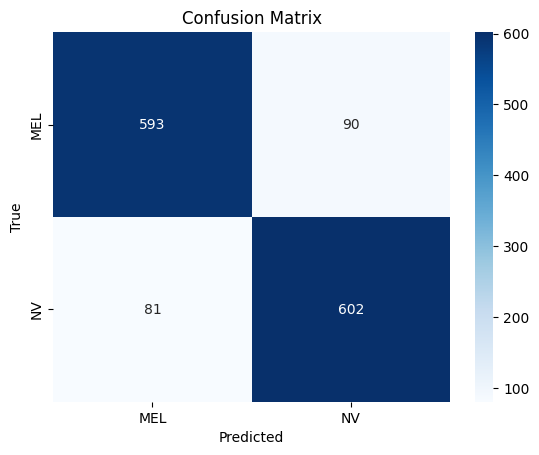

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, data_loader):
    all_gold = []
    all_pred = []
    
    
    for Xbatch, Ybatch in data_loader:
        Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
        outputs = model(Xbatch)
        predictions = (torch.sigmoid(outputs).squeeze() > 0.5).float()
        
        all_gold.extend(Ybatch.cpu().numpy())
        all_pred.extend(predictions.cpu().numpy())
    
    
    cm = confusion_matrix(all_gold, all_pred)

   
    print("Confusion Matrix:")
    print(cm)
    
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_dataset.classes, yticklabels=test_dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

plot_confusion_matrix(model_dinov_2, test_loader)


precision, recall and F score

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

def calculate_precision_recall_f1(model, data_loader):
    all_gold = []
    all_pred = []
    
    for Xbatch, Ybatch in data_loader:
        Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
        outputs = model(Xbatch)
        predictions = (torch.sigmoid(outputs).squeeze() > 0.5).float()
        
        all_gold.extend(Ybatch.cpu().numpy())
        all_pred.extend(predictions.cpu().numpy())

    precision = precision_score(all_gold, all_pred)
    recall = recall_score(all_gold, all_pred)
    f1 = f1_score(all_gold, all_pred)
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

calculate_precision_recall_f1(model_dinov_2, test_loader)


Precision: 0.8699, Recall: 0.8814, F1 Score: 0.8756


Precision-Recall Curve

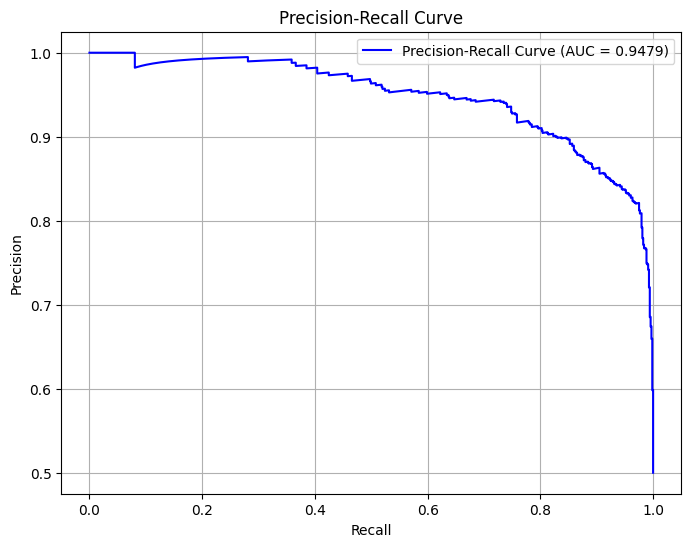

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

def plot_precision_recall_curve(model, data_loader):
    all_gold = []
    all_pred_prob = []
    
   
    for Xbatch, Ybatch in data_loader:
        Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
        outputs = model(Xbatch)
        
        
        all_gold.extend(Ybatch.cpu().numpy())
        
       
        all_pred_prob.extend(torch.sigmoid(outputs).detach().cpu().numpy())

    
    precision, recall, thresholds = precision_recall_curve(all_gold, all_pred_prob)
    
  
    pr_auc = auc(recall, precision)

   
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='blue', label=f'Precision-Recall Curve (AUC = {pr_auc:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()


plot_precision_recall_curve(model_dinov_2, test_loader)


Precision: 0.8699, Recall: 0.8814, F1 Score: 0.8756


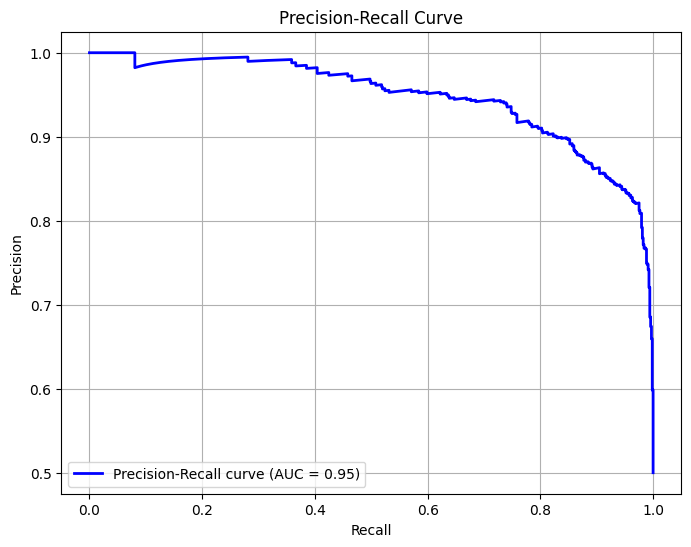

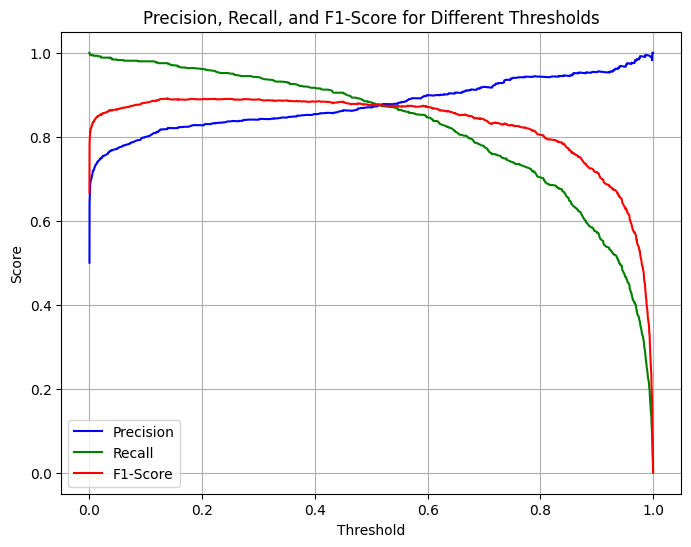

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def calculate_precision_recall_f1_and_plot(model, data_loader):
    all_gold = []
    all_pred_prob = []
    
   
    for Xbatch, Ybatch in data_loader:
        Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
        outputs = model(Xbatch)
        probabilities = torch.sigmoid(outputs).squeeze()
        
        all_gold.extend(Ybatch.cpu().numpy())
        all_pred_prob.extend(probabilities.detach().cpu().numpy())  

    
    all_pred = (torch.tensor(all_pred_prob) > 0.5).float().numpy()
    precision = precision_score(all_gold, all_pred)
    recall = recall_score(all_gold, all_pred)
    f1 = f1_score(all_gold, all_pred)
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")
    
  
    precision, recall, thresholds = precision_recall_curve(all_gold, all_pred_prob)
    pr_auc = auc(recall, precision)  
    

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower left')
    plt.grid(True)
    

    f1_scores = []
    for threshold in thresholds:
       
        preds = (np.array(all_pred_prob) > threshold).astype(float)
        f1_scores.append(f1_score(all_gold, preds))
    
   
    plt.figure(figsize=(8, 6))
    plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
    plt.plot(thresholds, recall[:-1], label='Recall', color='green')
    plt.plot(thresholds, f1_scores, label='F1-Score', color='red')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Precision, Recall, and F1-Score for Different Thresholds')
    plt.legend()
    plt.grid(True)
    plt.show()


calculate_precision_recall_f1_and_plot(model_dinov_2, test_loader)


ROC curve

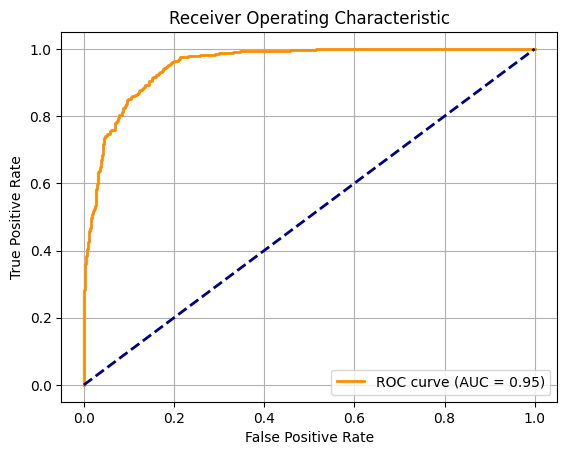

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_roc_curve(model, data_loader):
    all_gold = []
    all_pred_prob = []
    
    for Xbatch, Ybatch in data_loader:
        Xbatch, Ybatch = Xbatch.to(device), Ybatch.to(device)
        outputs = model(Xbatch)
        probabilities = torch.sigmoid(outputs).squeeze()
        
      
        all_gold.extend(Ybatch.cpu().numpy())
        all_pred_prob.extend(probabilities.detach().cpu().numpy()) 

    fpr, tpr, thresholds = roc_curve(all_gold, all_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

# Call the function to plot ROC curve
plot_roc_curve(model_dinov_2, test_loader)
